In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import sempler
import sempler.generators
import sempler.plot
import src.utils as utils
import src.metrics as metrics

import gnies.utils

import matplotlib
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib import gridspec

import seaborn as sns

import pickle
import os


import time

/home/juan/anaconda3/lib/python3.7/site-packages/rpy2/robjects/vectors.py:1008: UserWarning: R object inheriting from "POSIXct" but without attribute "tzone".
  warnings.warn('R object inheriting from "POSIXct" but without '
/home/juan/anaconda3/lib/python3.7/site-packages/pandas/core/arrays/datetimes.py:2192: PytzUsageWarning: The zone attribute is specific to pytz's interface; please migrate to a new time zone provider. For more details on how to do so, see https://pytz-deprecation-shim.readthedocs.io/en/latest/migration.html
  values, tz_parsed = conversion.datetime_to_datetime64(data.ravel("K"))


## Plotting setup

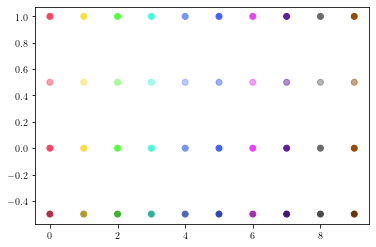

In [3]:
# Set tex formatting for plots
from matplotlib import rc
rc('font',**{'family':'serif','sans-serif':['Computer Modern Roman']})
rc('text', usetex=True)
plt.rc('text.latex', preamble=r'\usepackage{amsfonts}')
#plt.rcParams["font.family"] = "serif"
#plt.rcParams["font.serif"] = ["Computer Modern Roman"]

# Set legend size
from matplotlib.font_manager import FontProperties
fontP = FontProperties()
fontP.set_size('medium')

# Colors
def to_rgb(H, b=1, a=1):
    RGBa = []
    for h in H:
        h = h.lstrip("#")
        RGBa.append(tuple(int(h[i:i+2], 16) / 256 * b for i in (0, 2, 4)) + (a,))
    return np.array(RGBa)

cmap = matplotlib.cm.get_cmap('tab20')
# Colorblind safe palettes
base = ['#d73027', '#f46d43', '#fdae61', '#fee090', '#020202', '#abd9e9', '#74add1', '#4575b4']
#base = ['#b2182b', '#d6604d', '#f4a582', '#fddbc7', '#d1e5f0', '#92c5de', '#4393c3', '#2166ac']
#base = ['#8c510a', '#bf812d', '#dfc27d', '#f6e8c3', '#c7eae5', '#80cdc1', '#35978f', '#01665e']
# Rainbow palette
base = ["#ff4365", "#ffdd43", "#59ff43", "#43ffdd", "#7395ff", "#4365ff", "#e943ff", "#601e9e", "#6a6a6a", "#964b00"]#np.array([cmap(i) for i in range(2,20)])
plt.scatter(np.arange(len(base)), np.ones(len(base)), c = base)
#base = [base[i] for i in [0,1,3]]
colors = to_rgb(base)
colorsa = to_rgb(base, a=0.5)
colorsb = to_rgb(base, b=0.7)
plt.scatter(np.arange(len(colors)), np.zeros(len(colors)), c = colors)
plt.scatter(np.arange(len(colors)), np.ones(len(colors))*0.5, c = colorsa)
plt.scatter(np.arange(len(colors)), np.ones(len(colors))*-0.5, c = colorsb)

In [4]:
cred = "#FF6B6B"
cgreen = "#6BCB77"
cblue = "#4D96FF"

## To transform graph adjacencies into tikz graphs

In [5]:
def edges_to_adjacency(edges, variables):
    """Given edges encoded as a list of tuples, i.e. (from,to), encode as
    an adjacency matrix where `A[from,to] != 0` implies `from -> to`.
    """
    p = len(variables)
    idx = dict(zip(variables, range(p)))
    A = np.zeros((p, p))
    for fro, to in edges:
        if fro in variables and to in variables:
            fro = idx[fro]
            to = idx[to]
            A[fro, to] = 1
    return A


def points_on_circle(n, radius=1):
    """
    Coordinates of n equidistant points on a circle of given radius centered at (0,0).
    """
    theta = np.linspace(0, 2 * np.pi, n + 1)
    x = np.sin(theta)[:-1]
    y = np.cos(theta)[:-1]
    points = list(zip(x, y))
    points.reverse()
    return points

def graph_to_tikz(
    A, points=None, radius=1, labels=None, spaces=4, bend=None, undirected=False, weights=False
):
    """
    Transform an adjacency matrix A, where `A[i,j] != 0` implies `i -> j` into a latex tikz graph.
    """
    p = len(A)
    if points is None:
        points = points_on_circle(p, radius)
    if labels is None:
        labels = ["$X_{%d}$" % i for i in range(p)]
    indent = " " * spaces
    string = indent + "\\begin{tikzpicture}" + "\n"
    # Add nodes
    for j, (x, y) in enumerate(points):
        string += (
            indent
            + "    \\node[circle, inner sep=0.12em] (%d) at (%0.3f, %0.3f) {%s};\n"
            % (j, x * radius, y * radius, labels[j])
        )
    # Add edges
    string += indent + "    \\begin{scope}[]" + "\n"
    edges = sorted([(w,fro,to) for (fro,to),w in gnies.utils.edge_weights(A).items()])
    for (_,j,i) in edges:
        # Set tip
        if undirected and A[i, j] != 0:
            tip = "-, %s" % undirected
        else:
            tip = "->"
        # Set edge label
        if weights == 'color':
            c = 1-A[j,i]
            label = f"edge[color={{rgb,1:red,{c};green,{c};blue,{c}}}]"
        elif weights:
            label = f"{tip} node[pos=0.5, fill=white] {{\\tiny {A[j,i]:.2f}}}"
        else:
            label = "edge"
        # Set bend
        if bend is None:
            string += indent + "        \\draw[%s] (%d) %s (%d);\n" % (tip, j, label, i)
        else:
            jj, ii = 0, (i - j) % p
            direction = "left" if (ii - jj) < p / 2 else "right"
            #amount = abs(bend * (1 - (ii - jj) / p * 2))
            amount = bend * (1 - (ii - jj) / p * 2)
            bend_str = "bend %s=%d" % (direction, amount)
            string += indent + "        \\draw[%s, %s] (%d) %s (%d);\n" % (
                tip,
                bend_str,
                j,
                label,
                i,
            )
    string += indent + "    \\end{scope}" + "\n"
    string += indent + "\\end{tikzpicture}" + "\n"
    return string

## Visualize data

In [6]:
A = np.eye(5)
np.where(A != 0)

(array([0, 1, 2, 3, 4]), array([0, 1, 2, 3, 4]))

In [7]:
[(w,fro,to) for (fro,to),w in gnies.utils.edge_weights(A).items()]

[(1.0, 0, 0), (1.0, 1, 1), (1.0, 2, 2), (1.0, 3, 3), (1.0, 4, 4)]

In [8]:
from causalchamber.datasets import Dataset

# Download the dataset and store it, e.g., in the current directory
dataset = Dataset('lt_interventions_standard_v1', root='./', download=True)


Fetching list of available datasets from https://causalchamber.s3.eu-central-1.amazonaws.com/downloadables/directory.yaml ... done.
If you use our datasets or models for your work please consider citing:

@article{gamella2024chamber,
  title={The Causal Chambers: Real Physical Systems as a Testbed for AI Methodology},
  author={Gamella, Juan L. and B"uhlmann, Peter and Peters, Jonas},
  journal={arXiv preprint arXiv:2404.11341},
  year={2024}
}

Dataset lt_interventions_standard_v1 found in "lt_interventions_standard_v1".


In [9]:
n = 1000
df_ref = dataset.get_experiment(name='uniform_reference').as_pandas_dataframe().sample(n=n, random_state=42)
df_red = dataset.get_experiment(name='uniform_red_strong').as_pandas_dataframe().sample(n=n, random_state=42)
df_blue = dataset.get_experiment(name='uniform_blue_strong').as_pandas_dataframe().sample(n=n, random_state=42)
df_green = dataset.get_experiment(name='uniform_green_strong').as_pandas_dataframe().sample(n=n, random_state=42)
df_pol_1 = dataset.get_experiment(name='uniform_pol_1_strong').as_pandas_dataframe().sample(n=n, random_state=42)
df_pol_1_mid = dataset.get_experiment(name='uniform_pol_1_mid').as_pandas_dataframe().sample(n=n, random_state=42)
df_pol_2 = dataset.get_experiment(name='uniform_pol_2_strong').as_pandas_dataframe().sample(n=n, random_state=42)
df_angle_1 = dataset.get_experiment(name='uniform_v_angle_1_mid').as_pandas_dataframe().sample(n=n, random_state=42)
df_angle_2 = dataset.get_experiment(name='uniform_v_angle_2_mid').as_pandas_dataframe().sample(n=n, random_state=42)

In [10]:
import pandas as pd
pd.unique(df_angle_1.angle_1)

array([1023., 1014.,  972., 1021.,  952.,  954., 1001.,  953., 1005.,
        989., 1018.,  945.,  998.,  951., 1007.,  983.,  946.,  992.,
        968.,  971.,  944., 1008.,  958.,  993.,  979.,  977.,  985.,
        943.,  982., 1019.,  955.,  965.,  980.,  966.,  964.,  976.,
        949., 1020.,  999.,  997., 1009.,  974.,  996., 1016.,  963.,
        986.,  995.,  984.,  967., 1002.,  970.,  960.,  962., 1015.,
       1013.,  948.,  956., 1004.,  947.,  987.,  978.,  973.,  990.,
       1010.,  981.,  969.,  991., 1012.,  994., 1000.,  957., 1006.,
        961.,  959.,  988., 1017., 1011., 1003.,  975.,  950., 1022.,
        942.,  941.])

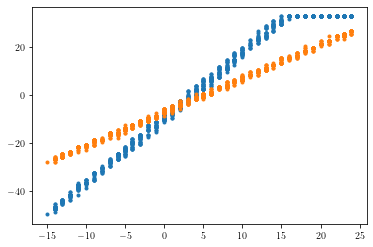

In [11]:
plt.scatter(df_angle_1.pol_1, df_angle_1.angle_1 - df_angle_1.angle_1.mean(), marker='.')
plt.scatter(df_ref.pol_1, df_ref.angle_1 - df_ref.angle_1.mean(), marker='.')

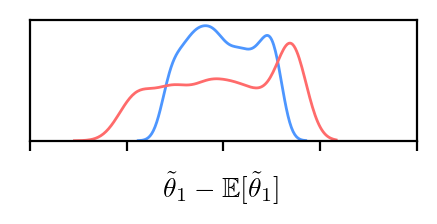

In [12]:
plt.figure(figsize=(2.5,0.8), dpi=200)
kwargs = {'linewidth': 1}
sns.kdeplot(df_ref.angle_1 - df_ref.angle_1.mean(), label=r"Reference", **kwargs, color=cblue)
sns.kdeplot(df_angle_1.angle_1 - df_angle_1.angle_1.mean(), label=r"Int. on $\tilde{\theta}_1$", **kwargs, color=cred)
plt.xlabel(r"$\tilde{\theta}_1 - \mathbb{E}[\tilde{\theta}_1]$")
plt.xticks([-90,-45,0,45,90], [])
plt.yticks([])
plt.ylabel("")
plt.savefig("figures/density_angle_1.pdf", bbox_inches="tight")

In [13]:
n = 700
df_ref = dataset.get_experiment(name='uniform_reference').as_pandas_dataframe().sample(n=n, random_state=42)
df_red = dataset.get_experiment(name='uniform_red_strong').as_pandas_dataframe().sample(n=n, random_state=42)
df_blue = dataset.get_experiment(name='uniform_blue_strong').as_pandas_dataframe().sample(n=n, random_state=42)
df_green = dataset.get_experiment(name='uniform_green_strong').as_pandas_dataframe().sample(n=n, random_state=42)
df_pol_1 = dataset.get_experiment(name='uniform_pol_1_strong').as_pandas_dataframe().sample(n=n, random_state=42)
df_pol_1_mid = dataset.get_experiment(name='uniform_pol_1_mid').as_pandas_dataframe().sample(n=n, random_state=42)
df_pol_2 = dataset.get_experiment(name='uniform_pol_2_strong').as_pandas_dataframe().sample(n=n, random_state=42)
df_angle_1 = dataset.get_experiment(name='uniform_v_angle_1_mid').as_pandas_dataframe().sample(n=n, random_state=42)
df_angle_2 = dataset.get_experiment(name='uniform_v_angle_2_mid').as_pandas_dataframe().sample(n=n, random_state=42)

-91.29246921949562 [4.09525746]
-4.477845649903614 [0.45258424]


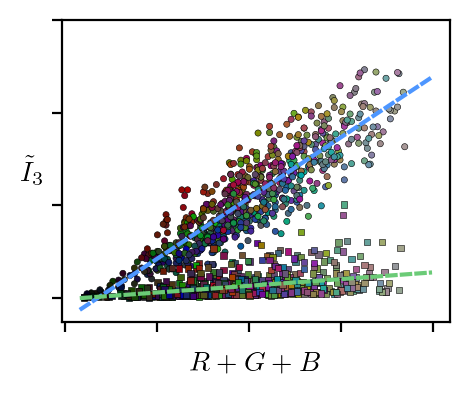

In [14]:
plt.figure(figsize=(2.5,2), dpi=200)
kwargs = {'s': 5, 'linewidth': 0.2, 'edgecolor': 'black'}

x_ref = df_ref[['red', 'green', 'blue']].values.sum(axis=1)
y_ref = df_ref.ir_3,
c_ref = df_ref[['red', 'green', 'blue']].values / 255 * 2
plt.scatter(x_ref, y_ref, c=c_ref, **kwargs, marker='o')

x_pol_1 = df_pol_1[['red', 'green', 'blue']].values.sum(axis=1)
y_pol_1 = df_pol_1.ir_3,
c_pol_1 = df_pol_1[['red', 'green', 'blue']].values / 255 * 2
plt.scatter(x_pol_1, y_pol_1, c=c_pol_1, **kwargs, marker='s')

plt.xlabel("$R + G + B$")
plt.ylabel(r"$\tilde{I}_3$", rotation=0, va="center")

# Regression lines

# reference
from sklearn.linear_model import LinearRegression
X_ref = df_ref[['red', 'green', 'blue']].values.sum(axis=1, keepdims=True)
reg = LinearRegression().fit(X_ref, df_ref.ir_3.values)
x1, x2 = 10, 255
print(reg.intercept_, reg.coef_)
b0,b1 = reg.intercept_, reg.coef_[0]
plt.plot([x1, x2], [b0 + b1*x1, b0 + b1*x2], color=cblue, linewidth=1.5, linestyle=(0,(3,0.5)))

# pol_1
X_ref = df_pol_1[['red', 'green', 'blue']].values.sum(axis=1, keepdims=True)
reg = LinearRegression().fit(X_ref, df_pol_1.ir_3.values)
print(reg.intercept_, reg.coef_)
b0,b1 = reg.intercept_, reg.coef_[0]
plt.plot([x1, x2], [b0 + b1*x1, b0 + b1*x2], color=cgreen, linewidth=1.5, linestyle=(0,(3,0.5)))

# Build legend
method_entries = [Line2D([0], [0],
                         linewidth=0,
                         linestyle=None,
                         marker='.',
                         color=c) for c in ['gray', cred, cgreen, cblue, 'black']]
method_str = [r'$I = \emptyset$',
              r'$I = \{R\}$',
              r'$I = \{G\}$',
              r'$I = \{B\}$',
              r'$I = \{\theta_1\}$',
             ]

plt.xticks([0,64,128,128+64,256], [])
plt.yticks([0,400,800,1200], [])
plt.savefig("figures/scatter_lt.pdf", bbox_inches="tight")

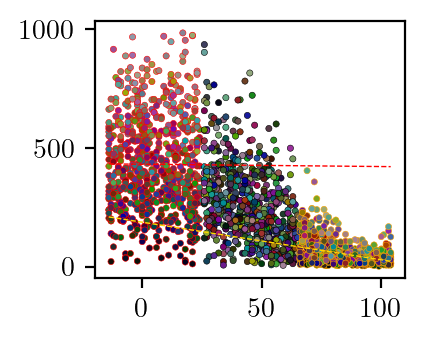

In [15]:
from sklearn.linear_model import LinearRegression

plt.figure(figsize=(2,1.7), dpi=200)
kwargs = {'s': 5, 'marker': 'o', 'linewidth': 0.2}
c_ref = df_ref[['red', 'green', 'blue']].values / 255 * 2
c_pol_1 = df_pol_1[['red', 'green', 'blue']].values / 255 * 2
c_pol_1_mid = df_pol_1_mid[['red', 'green', 'blue']].values / 255 * 2
#plt.scatter(df_ref.pol_1, df_ref.ir_3 - df_ref.ir_3.mean(), c=c_ref, **kwargs)
#plt.scatter(df_pol_1.pol_1, df_pol_1.ir_3 - df_pol_1.ir_3.mean(), c=c_pol_1, **kwargs)
plt.scatter(df_ref.pol_1, df_ref.ir_3, c=c_ref, **kwargs, edgecolor='red')
plt.scatter(df_pol_1_mid.pol_1, df_pol_1_mid.ir_3, c=c_pol_1, **kwargs, edgecolor='black')
plt.scatter(df_pol_1.pol_1, df_pol_1.ir_3, c=c_pol_1, **kwargs, edgecolor='orange')

# Slopes in ref and pol_1 environments    
X_ref = np.atleast_2d(df_ref.pol_1)
reg = LinearRegression().fit(X_ref.T, df_ref.ir_3.values)
x1, x2 = df_ref.pol_1.min(), df_pol_1.pol_1.max()
b0,b1 = reg.intercept_, reg.coef_[0]
plt.plot([x1, x2], [b0 + b1*x1, b0 + b1*x2], color='red', linewidth=0.5, linestyle="--")

X_pol_1 = np.atleast_2d(df_pol_1.pol_1)
reg = LinearRegression().fit(X_pol_1.T, df_pol_1.ir_3.values)
x1, x2 = df_ref.pol_1.min(), df_pol_1.pol_1.max()
b0,b1 = reg.intercept_, reg.coef_[0]
plt.plot([x1, x2], [b0 + b1*x1, b0 + b1*x2], color='gold', linewidth=0.5, linestyle="--")

## Plot & graphs for $\mathcal{I}^\star = \emptyset$

In [16]:
directory = "light_tunnel_experiments/dataset_1718986239_light_tunnel_tag:ref/"
test_cases = utils.read_pickle(directory + 'test_cases.pickle')
Ns = sorted(test_cases['Ns'])

**GnIES**

In [17]:
gnies_args, gnies_results = utils.read_pickle(directory + "compiled_results_gnies_fb.pickle")
ground_truth, gnies_metrics = utils.read_pickle(directory + "metrics_gnies_fb.pickle")
gnies_lambdas = gnies_args[2]
print(gnies_lambdas)
print(gnies_metrics[metrics.success_metric].mean())

gnies_x = np.nanmean(gnies_metrics[metrics.type_1_structc], axis=(0,3))
gnies_y = np.nanmean(gnies_metrics[metrics.type_2_structc], axis=(0,3))

[0.01, 0.25, 0.5, 0.75, 1.0, 2.0]
1.0


**GnIES w. means**

In [18]:
gniesm_args, gniesm_results = utils.read_pickle(directory + "compiled_results_gnies_fb_means.pickle")
ground_truth, gniesm_metrics = utils.read_pickle(directory + "metrics_gnies_fb_means.pickle")
gniesm_lambdas = gniesm_args[2]
print(gniesm_lambdas)
print(gniesm_metrics[metrics.success_metric].mean())

gniesm_x = np.nanmean(gniesm_metrics[metrics.type_1_structc], axis=(0,3))
gniesm_y = np.nanmean(gniesm_metrics[metrics.type_2_structc], axis=(0,3))

[0.01, 0.25, 0.5, 0.75, 1.0, 2.0]
1.0


**UT-IGSP**

In [19]:
ut_igsp_args, ut_igsp_results = utils.read_pickle(directory + "compiled_results_ut_igsp_gauss_obs:0.pickle")
ground_truth, utigsp_metrics = utils.read_pickle(directory + "metrics_ut_igsp_gauss_obs:0.pickle")
utigsp_alphas, utigsp_betas = ut_igsp_args[1], ut_igsp_args[2]
print(utigsp_alphas, utigsp_betas)
print(utigsp_metrics[metrics.success_metric].mean(axis=(0,1,2,4)))
print(utigsp_metrics[metrics.type_1_structc].shape)

idx = list(range(len(utigsp_alphas)))
UTIGSP_BETA = 1
utigsp_x = np.nanmean(utigsp_metrics[metrics.type_1_structc], axis=(0,4))[idx,[UTIGSP_BETA]]
utigsp_y = np.nanmean(utigsp_metrics[metrics.type_2_structc], axis=(0,4))[idx,[UTIGSP_BETA]]

[0.001, 0.01, 0.05, 0.1, 0.2, 0.3, 0.4, 0.5] [1e-10, 0.001, 0.01, 0.1]
[1.]
(1, 8, 4, 1, 100)


**UT-IGSP with HSIC tests**

In [20]:
ut_igspH_args, ut_igspH_results = utils.read_pickle(directory + "compiled_results_ut_igsp_hsic_obs:0.pickle")
ground_truth, utigspH_metrics = utils.read_pickle(directory + "metrics_ut_igsp_hsic_obs:0.pickle")
utigspH_alphas, utigspH_betas = ut_igspH_args[1], ut_igspH_args[2]
print(utigspH_alphas, utigspH_betas)
print(utigspH_metrics[metrics.success_metric].mean(axis=(0,1,2,4)))
print(utigspH_metrics[metrics.type_1_structc].shape)

idx = list(range(len(utigspH_alphas)))
utigspH_x = np.nanmean(utigspH_metrics[metrics.type_1_structc], axis=(0,4))[idx,[UTIGSP_BETA]]
utigspH_y = np.nanmean(utigspH_metrics[metrics.type_2_structc], axis=(0,4))[idx,[UTIGSP_BETA]]

[0.001, 0.01, 0.05, 0.1, 0.2, 0.3, 0.4, 0.5] [1e-10, 0.001, 0.01, 0.1]
[1.]
(1, 8, 4, 1, 100)


**GES**

In [21]:
ges_args, ges_results = utils.read_pickle(directory + "compiled_results_ges.pickle")
ground_truth, ges_metrics = utils.read_pickle(directory + "metrics_ges.pickle")
ges_lambdas = ges_args[2]
print(ges_lambdas)
print(ges_metrics[metrics.success_metric].mean())

ges_x = np.nanmean(ges_metrics[metrics.type_1_structc], axis=(0,3))
ges_y = np.nanmean(ges_metrics[metrics.type_2_structc], axis=(0,3))

[0.01, 0.25, 0.5, 0.75, 1.0, 2.0]
1.0


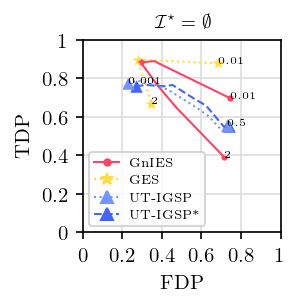

In [22]:
# -------------------------------------------------------------------
# Plot
text = True
textsize = 5
lineopts = {'linewidth': 1}
ticks = [0, 0.2, 0.4, 0.6, 0.8, 1]
marker = {'gnies': '.',
          'gnies_means': '.',
          'gnies_rank': '.',
          'ges': '*',
          'ut_igsp': '^',
          'ut_igsp+': '^',
          'sort': 's',
          'sortp': 'X',           
}
style = {'gnies': '-',
         'gnies_means': '--',
         'gnies_rank': ':',
         'ges': ':',
         'ut_igsp': ':',
         'ut_igsp+': '--',
         'sort': ':',
         'sortp': '--',
           
}
color = {'gnies': colors[0],
         'gnies_means': colors[0],
         'gnies_rank': colorsa[0],
         'ges': colors[1],
         'ut_igsp': colors[4],
         'ut_igsp+': colors[5],
         'sort': colors[2],
         'sortp': colors[2],
         
}

print_names = {'gnies': 'GnIES',
               #'gnies_means': 'GnIES means',
               #'gnies_rank': 'GnIES-rank',
               'ges': 'GES',
               'ut_igsp': 'UT-IGSP',
               'ut_igsp+': 'UT-IGSP*',
               #'sort': 'sortnregress',         
               #'sortp': 'sortnregress',
}

def plot_metric(ax, values_x, values_y, lambdas, method, points, text, gray=False):
    c = '#aaaaaa' if gray else color[method]
    values_y = 1 - values_y
    ax.plot(values_x, values_y, color=c, linestyle=style[method], **lineopts)
    for j, l in enumerate(lambdas):
        #ax.scatter(values_x[j], values_y[j], color=color[method], marker=".", linewidth=0)
        if j==0 and text[0] is not None:
            if l < 0.001:
                l = np.log10(l)
                fmt = "$10^{%d}$"
            else:
                fmt = "$"+text[0]+"$"
            ax.text(values_x[j], values_y[j], fmt % l, fontsize=textsize, ha="left")
        if l==lambdas[-1] and text[1] is not None:
            ax.text(values_x[j], values_y[j], ("$"+text[1]+"$") % l, fontsize=textsize, ha="left")
        if j in points:
            ax.scatter(values_x[j], values_y[j], color=c, marker=marker[method], linewidth=0)
            
def set_ax(ax, yticks=True):
    ax.set_xlim([0,1])
    ax.set_ylim([0,1])
    ax.set_xlabel('FDP')    
    ax.set_ylabel('TDP') if yticks else None
    ax.set_yticks(ticks)
    ax.set_xticks(ticks)
    ax.set_xticklabels(ticks)
    ax.set_yticklabels(ticks) if yticks else ax.set_yticklabels([])


gs = gridspec.GridSpec(1, 1, wspace=0.10, hspace=0.2)
plt.figure(figsize=(1.7,1.7), dpi=150)
ax = plt.gca()

for i,n in enumerate(Ns):
    plt.subplot(gs[i])
    ax = plt.gca()
    if i==0:
        ax0 = ax
    
    # Plot GES
    plot_metric(ax, ges_x[:,i], ges_y[:,i], ges_lambdas, 'ges', [0,2,len(ges_lambdas)-1], ["%0.2f","%d"])    
    
    # Plot GnIES
    plot_metric(ax, gnies_x[:,i], gnies_y[:,i], gnies_lambdas, 'gnies', [0,2,len(gnies_lambdas)-1], ["%0.2f","%d"])
    
    # Plot GnIES means
    #plot_metric(ax, gniesm_x[:,i], gniesm_y[:,i], gniesm_lambdas, 'gnies_means', [0,2,len(gniesm_lambdas)-1], [None if n==10 else "%0.2f","%0.1f"])
                
    # Plot UT-IGSP HSIC
    plot_metric(ax, utigspH_x[:,i], utigspH_y[:,i], utigspH_alphas, 'ut_igsp+', [0,len(utigsp_alphas)-1], [None, None])
    
    # Plot UT-IGSP
    plot_metric(ax, utigsp_x[:,i], utigsp_y[:,i], utigsp_alphas, 'ut_igsp', [0,len(utigsp_alphas)-1], ["%0.3f","%0.1f"])

    
    
    set_ax(ax, yticks=i==0)
    ax.set_title("%d obs./environment" % n)    
    ax.set_title(r"$\mathcal{I}^\star = \emptyset$", fontsize=9)


# Build legend
method_entries = [Line2D([0], [0],
                         linewidth=1,
                         linestyle=style[method],
                         marker=marker[method],
                         color=color[method]) for method in print_names.keys()]
method_str = list(print_names.values())
ax.legend(method_entries, #+ sample_size_entries
          method_str, # + sample_size_str
          prop={'size':6},
          loc='lower left',
        ncol=1)

plt.grid(color='#dddddd')
plt.savefig('figures/figure_lt_ref.pdf', bbox_inches='tight')

### Graphs

#### Ground truth

In [23]:
import causalchamber.ground_truth as gt
from causalchamber.ground_truth import latex_name

variables=test_cases['variables']

true_dag = gt.graph('lt', 'standard').loc[variables, variables].values
print(graph_to_tikz(true_dag, radius=1.5, bend=10, labels=[latex_name(v) for v in variables], weights="color"))

    \begin{tikzpicture}
        \node[circle, inner sep=0.12em] (0) at (-0.811, 1.262) {$R$};
        \node[circle, inner sep=0.12em] (1) at (-1.364, 0.623) {$G$};
        \node[circle, inner sep=0.12em] (2) at (-1.485, -0.213) {$B$};
        \node[circle, inner sep=0.12em] (3) at (-1.134, -0.982) {$\tilde{C}$};
        \node[circle, inner sep=0.12em] (4) at (-0.423, -1.439) {$\tilde{I}_1$};
        \node[circle, inner sep=0.12em] (5) at (0.423, -1.439) {$\tilde{I}_2$};
        \node[circle, inner sep=0.12em] (6) at (1.134, -0.982) {$\tilde{I}_3$};
        \node[circle, inner sep=0.12em] (7) at (1.485, -0.213) {$\theta_1$};
        \node[circle, inner sep=0.12em] (8) at (1.364, 0.623) {$\tilde{\theta}_1$};
        \node[circle, inner sep=0.12em] (9) at (0.811, 1.262) {$\theta_2$};
        \node[circle, inner sep=0.12em] (10) at (0.000, 1.500) {$\tilde{\theta}_2$};
        \begin{scope}[]
            \draw[->, bend left=4] (0) edge[color={rgb,1:red,0;green,0;blue,0}] (3);
            \d

#### GnIES

[0.01, 0.25, 0.5, 0.75, 1.0, 2.0] [1000]
lambda=0.5, n=1000


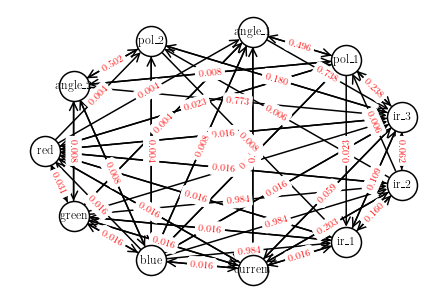

    \begin{tikzpicture}
        \node[circle, inner sep=0.12em] (0) at (-0.811, 1.262) {$R$};
        \node[circle, inner sep=0.12em] (1) at (-1.364, 0.623) {$G$};
        \node[circle, inner sep=0.12em] (2) at (-1.485, -0.213) {$B$};
        \node[circle, inner sep=0.12em] (3) at (-1.134, -0.982) {$\tilde{C}$};
        \node[circle, inner sep=0.12em] (4) at (-0.423, -1.439) {$\tilde{I}_1$};
        \node[circle, inner sep=0.12em] (5) at (0.423, -1.439) {$\tilde{I}_2$};
        \node[circle, inner sep=0.12em] (6) at (1.134, -0.982) {$\tilde{I}_3$};
        \node[circle, inner sep=0.12em] (7) at (1.485, -0.213) {$\theta_1$};
        \node[circle, inner sep=0.12em] (8) at (1.364, 0.623) {$\tilde{\theta}_1$};
        \node[circle, inner sep=0.12em] (9) at (0.811, 1.262) {$\theta_2$};
        \node[circle, inner sep=0.12em] (10) at (0.000, 1.500) {$\tilde{\theta}_2$};
        \begin{scope}[]
            \draw[->, bend right=-2] (1) edge[color={rgb,1:red,0.998046875;green,0.998046875;blue,0

In [24]:
print(gnies_lambdas, Ns)
i = 2
j = 0
print(f"lambda={gnies_lambdas[i]}, n={Ns[j]}")
estimates = gnies_results['estimates'][0,i,j,:]
dags = []
for e in estimates:
    dags += list(gnies.utils.all_dags(e))        
    average = np.sum(dags, axis=0) / len(dags)
sempler.plot.plot_graph(average, labels=test_cases['variables'], weights=True)
        

print(graph_to_tikz(average, radius=1.5, bend=10, labels=[latex_name(v) for v in test_cases['variables']], weights="color"))

#### GES

[0.01, 0.25, 0.5, 0.75, 1.0, 2.0] [1000]
lambda=1.0, n=1000


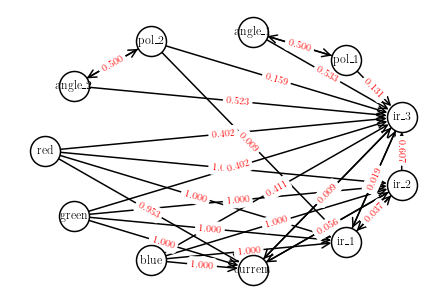

    \begin{tikzpicture}
        \node[circle, inner sep=0.12em] (0) at (-0.811, 1.262) {$R$};
        \node[circle, inner sep=0.12em] (1) at (-1.364, 0.623) {$G$};
        \node[circle, inner sep=0.12em] (2) at (-1.485, -0.213) {$B$};
        \node[circle, inner sep=0.12em] (3) at (-1.134, -0.982) {$\tilde{C}$};
        \node[circle, inner sep=0.12em] (4) at (-0.423, -1.439) {$\tilde{I}_1$};
        \node[circle, inner sep=0.12em] (5) at (0.423, -1.439) {$\tilde{I}_2$};
        \node[circle, inner sep=0.12em] (6) at (1.134, -0.982) {$\tilde{I}_3$};
        \node[circle, inner sep=0.12em] (7) at (1.485, -0.213) {$\theta_1$};
        \node[circle, inner sep=0.12em] (8) at (1.364, 0.623) {$\tilde{\theta}_1$};
        \node[circle, inner sep=0.12em] (9) at (0.811, 1.262) {$\theta_2$};
        \node[circle, inner sep=0.12em] (10) at (0.000, 1.500) {$\tilde{\theta}_2$};
        \begin{scope}[]
            \draw[->, bend left=6] (3) edge[color={rgb,1:red,0.9906542056074766;green,0.99065420560

In [25]:
print(ges_lambdas, Ns)
i = 4
j = 0
print(f"lambda={ges_lambdas[i]}, n={Ns[j]}")
estimates = ges_results['estimates'][0,i,j,:]
dags = []
for e in estimates:
    dags += list(gnies.utils.all_dags(e))        
    average = np.sum(dags, axis=0) / len(dags)
sempler.plot.plot_graph(average, labels=test_cases['variables'], weights=True)
        

print(graph_to_tikz(average, radius=1.5, bend=10, labels=[latex_name(v) for v in test_cases['variables']], weights="color"))

#### UT-IGSP

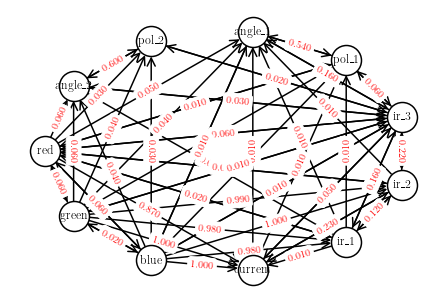

    \begin{tikzpicture}
        \node[circle, inner sep=0.12em] (0) at (-0.811, 1.262) {$R$};
        \node[circle, inner sep=0.12em] (1) at (-1.364, 0.623) {$G$};
        \node[circle, inner sep=0.12em] (2) at (-1.485, -0.213) {$B$};
        \node[circle, inner sep=0.12em] (3) at (-1.134, -0.982) {$\tilde{C}$};
        \node[circle, inner sep=0.12em] (4) at (-0.423, -1.439) {$\tilde{I}_1$};
        \node[circle, inner sep=0.12em] (5) at (0.423, -1.439) {$\tilde{I}_2$};
        \node[circle, inner sep=0.12em] (6) at (1.134, -0.982) {$\tilde{I}_3$};
        \node[circle, inner sep=0.12em] (7) at (1.485, -0.213) {$\theta_1$};
        \node[circle, inner sep=0.12em] (8) at (1.364, 0.623) {$\tilde{\theta}_1$};
        \node[circle, inner sep=0.12em] (9) at (0.811, 1.262) {$\theta_2$};
        \node[circle, inner sep=0.12em] (10) at (0.000, 1.500) {$\tilde{\theta}_2$};
        \begin{scope}[]
            \draw[->, bend left=6] (0) edge[color={rgb,1:red,0.99;green,0.99;blue,0.99}] (2);
     

In [26]:
ut_igsp_args, ut_igsp_results
estimates = ut_igsp_results['estimates'][0,UTIGSP_BETA,0,0,:]
average = np.sum(estimates, axis=0) / len(estimates)
sempler.plot.plot_graph(average, labels=test_cases['variables'], weights=True)
        
from causalchamber.ground_truth import latex_name
print(graph_to_tikz(average, radius=1.5, bend=10, labels=[latex_name(v) for v in test_cases['variables']], weights="color"))

## Plot & graphs for $\mathcal{I}^\star = \{\tilde{\theta}_1, \tilde{\theta}_2\}$

In [27]:
directory = "light_tunnel_experiments/dataset_1718986313_light_tunnel_tag:angles/"

test_cases = utils.read_pickle(directory + 'test_cases.pickle')
Ns = sorted(test_cases['Ns'])

**GnIES**

In [28]:
gnies_args, gnies_results = utils.read_pickle(directory + "compiled_results_gnies_fb.pickle")
ground_truth, gnies_metrics = utils.read_pickle(directory + "metrics_gnies_fb.pickle")
gnies_lambdas = gnies_args[2]
print(gnies_lambdas)
print(gnies_metrics[metrics.success_metric].mean())

gnies_x = np.nanmean(gnies_metrics[metrics.type_1_structc], axis=(0,3))
gnies_y = np.nanmean(gnies_metrics[metrics.type_2_structc], axis=(0,3))

[0.01, 0.25, 0.5, 0.75, 1.0, 2.0]
1.0


**GnIES w. means**

In [29]:
gniesm_args, gniesm_results = utils.read_pickle(directory + "compiled_results_gnies_fb_means.pickle")
ground_truth, gniesm_metrics = utils.read_pickle(directory + "metrics_gnies_fb_means.pickle")
gniesm_lambdas = gniesm_args[2]
print(gniesm_lambdas)
print(gniesm_metrics[metrics.success_metric].mean())

gniesm_x = np.nanmean(gniesm_metrics[metrics.type_1_structc], axis=(0,3))
gniesm_y = np.nanmean(gniesm_metrics[metrics.type_2_structc], axis=(0,3))

[0.01, 0.25, 0.5, 0.75, 1.0, 2.0]
1.0


**UT-IGSP**

In [30]:
ut_igsp_args, ut_igsp_results = utils.read_pickle(directory + "compiled_results_ut_igsp_gauss_obs:0.pickle")
ground_truth, utigsp_metrics = utils.read_pickle(directory + "metrics_ut_igsp_gauss_obs:0.pickle")
utigsp_alphas, utigsp_betas = ut_igsp_args[1], ut_igsp_args[2]
print(utigsp_alphas, utigsp_betas)
print(utigsp_metrics[metrics.success_metric].mean(axis=(0,1,2,4)))
print(utigsp_metrics[metrics.type_1_structc].shape)

idx = list(range(len(utigsp_alphas)))
utigsp_x = np.nanmean(utigsp_metrics[metrics.type_1_structc], axis=(0,4))[idx,[UTIGSP_BETA]]
utigsp_y = np.nanmean(utigsp_metrics[metrics.type_2_structc], axis=(0,4))[idx,[UTIGSP_BETA]]

[0.001, 0.01, 0.05, 0.1, 0.2, 0.3, 0.4, 0.5] [1e-10, 0.001, 0.01, 0.1]
[1.]
(1, 8, 4, 1, 100)


**UT-IGSP with HSIC tests**

In [31]:
ut_igspH_args, ut_igspH_results = utils.read_pickle(directory + "compiled_results_ut_igsp_hsic_obs:0.pickle")
ground_truth, utigspH_metrics = utils.read_pickle(directory + "metrics_ut_igsp_hsic_obs:0.pickle")
utigspH_alphas, utigspH_betas = ut_igspH_args[1], ut_igspH_args[2]
print(utigspH_alphas, utigspH_betas)
print(utigspH_metrics[metrics.success_metric].mean(axis=(0,1,2,4)))
print(utigspH_metrics[metrics.type_1_structc].shape)

idx = list(range(len(utigspH_alphas)))
utigspH_x = np.nanmean(utigspH_metrics[metrics.type_1_structc], axis=(0,4))[idx,[UTIGSP_BETA]]
utigspH_y = np.nanmean(utigspH_metrics[metrics.type_2_structc], axis=(0,4))[idx,[UTIGSP_BETA]]

[0.001, 0.01, 0.05, 0.1, 0.2, 0.3, 0.4, 0.5] [1e-10, 0.001, 0.01, 0.1]
[1.]
(1, 8, 4, 1, 100)


**GES**

In [32]:
ges_args, ges_results = utils.read_pickle(directory + "compiled_results_ges.pickle")
ground_truth, ges_metrics = utils.read_pickle(directory + "metrics_ges.pickle")
ges_lambdas = ges_args[2]
print(ges_lambdas)
print(ges_metrics[metrics.success_metric].mean())

ges_x = np.nanmean(ges_metrics[metrics.type_1_structc], axis=(0,3))
ges_y = np.nanmean(ges_metrics[metrics.type_2_structc], axis=(0,3))

[0.01, 0.25, 0.5, 0.75, 1.0, 2.0]
1.0


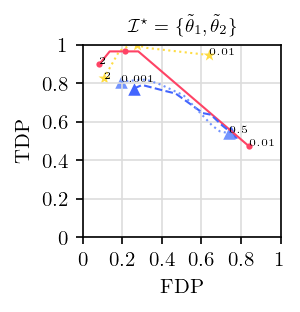

In [33]:
# -------------------------------------------------------------------
# Plot
text = True
textsize = 5
lineopts = {'linewidth': 1}
ticks = [0, 0.2, 0.4, 0.6, 0.8, 1]
marker = {'gnies': '.',
          'gnies_means': '.',
          'gnies_rank': '.',
          'ges': '*',
          'ut_igsp': '^',
          'ut_igsp+': '^',
          'sort': 's',
          'sortp': 'X',           
}
style = {'gnies': '-',
         'gnies_means': '--',
         'gnies_rank': ':',
         'ges': ':',
         'ut_igsp': ':',
         'ut_igsp+': '--',
         'sort': ':',
         'sortp': '--',
           
}
color = {'gnies': colors[0],
         'gnies_means': colors[0],
         'gnies_rank': colorsa[0],
         'ges': colors[1],
         'ut_igsp': colors[4],
         'ut_igsp+': colors[5],
         'sort': colors[2],
         'sortp': colors[2],
         
}

print_names = {'gnies': 'GnIES',
               #'gnies_means': 'GnIES means',
               #'gnies_rank': 'GnIES-rank',
               'ges': 'GES',
               'ut_igsp': 'UT-IGSP',
               'ut_igsp+': 'UT-IGSP*',
               #'sort': 'sortnregress',         
               #'sortp': 'sortnregress',
}

def plot_metric(ax, values_x, values_y, lambdas, method, points, text, gray=False):
    c = '#aaaaaa' if gray else color[method]
    values_y = 1 - values_y
    ax.plot(values_x, values_y, color=c, linestyle=style[method], **lineopts)
    for j, l in enumerate(lambdas):
        #ax.scatter(values_x[j], values_y[j], color=color[method], marker=".", linewidth=0)
        if j==0 and text[0] is not None:
            if l < 0.001:
                l = np.log10(l)
                fmt = "$10^{%d}$"
            else:
                fmt = "$"+text[0]+"$"
            ax.text(values_x[j], values_y[j], fmt % l, fontsize=textsize, ha="left")
        if l==lambdas[-1] and text[1] is not None:
            ax.text(values_x[j], values_y[j], ("$"+text[1]+"$") % l, fontsize=textsize, ha="left")
        if j in points:
            ax.scatter(values_x[j], values_y[j], color=c, marker=marker[method], linewidth=0)
            
def set_ax(ax, yticks=True):
    ax.set_xlim([0,1])
    ax.set_ylim([0,1])
    ax.set_xlabel('FDP')    
    ax.set_ylabel('TDP') if yticks else None
    ax.set_yticks(ticks)
    ax.set_xticks(ticks)
    ax.set_xticklabels(ticks)
    ax.set_yticklabels(ticks) if yticks else ax.set_yticklabels([])


gs = gridspec.GridSpec(1, 1, wspace=0.10, hspace=0.2)
plt.figure(figsize=(1.7,1.7), dpi=150)
ax = plt.gca()

for i,n in enumerate(Ns):
    plt.subplot(gs[i])
    ax = plt.gca()
    if i==0:
        ax0 = ax
    
    # Plot GES
    plot_metric(ax, ges_x[:,i], ges_y[:,i], ges_lambdas, 'ges', [0,2,len(ges_lambdas)-1], ["%0.2f","%d"])    
    
    # Plot GnIES
    plot_metric(ax, gnies_x[:,i], gnies_y[:,i], gnies_lambdas, 'gnies', [0,2,len(gnies_lambdas)-1], ["%0.2f","%d"])
    
    # Plot GnIES means
    #plot_metric(ax, gniesm_x[:,i], gniesm_y[:,i], gniesm_lambdas, 'gnies_means', [0,2,len(gniesm_lambdas)-1], [None if n==10 else "%0.2f","%0.1f"])
                
    # Plot UT-IGSP HSIC
    plot_metric(ax, utigspH_x[:,i], utigspH_y[:,i], utigspH_alphas, 'ut_igsp+', [0,len(utigsp_alphas)-1], [None, None])
    
    # Plot UT-IGSP
    plot_metric(ax, utigsp_x[:,i], utigsp_y[:,i], utigsp_alphas, 'ut_igsp', [0,len(utigsp_alphas)-1], ["%0.3f","%0.1f"])

    
    
    set_ax(ax, yticks=i==0)
    ax.set_title("%d obs./environment" % n)    
    ax.set_title(r"$\mathcal{I}^\star = \{\tilde{\theta}_1, \tilde{\theta}_2\}$", fontsize=9)

plt.grid(color='#dddddd')
plt.savefig('figures/figure_lt_angles.pdf', bbox_inches='tight')

### Graphs

#### GnIES

[0.01, 0.25, 0.5, 0.75, 1.0, 2.0] [1000]
lambda=0.5, n=1000


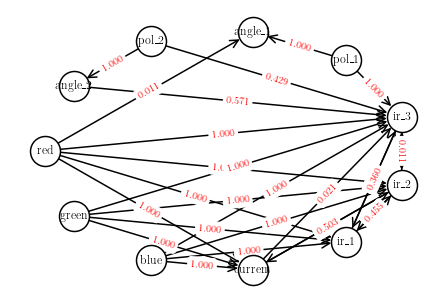

    \begin{tikzpicture}
        \node[circle, inner sep=0.12em] (0) at (-0.811, 1.262) {$R$};
        \node[circle, inner sep=0.12em] (1) at (-1.364, 0.623) {$G$};
        \node[circle, inner sep=0.12em] (2) at (-1.485, -0.213) {$B$};
        \node[circle, inner sep=0.12em] (3) at (-1.134, -0.982) {$\tilde{C}$};
        \node[circle, inner sep=0.12em] (4) at (-0.423, -1.439) {$\tilde{I}_1$};
        \node[circle, inner sep=0.12em] (5) at (0.423, -1.439) {$\tilde{I}_2$};
        \node[circle, inner sep=0.12em] (6) at (1.134, -0.982) {$\tilde{I}_3$};
        \node[circle, inner sep=0.12em] (7) at (1.485, -0.213) {$\theta_1$};
        \node[circle, inner sep=0.12em] (8) at (1.364, 0.623) {$\tilde{\theta}_1$};
        \node[circle, inner sep=0.12em] (9) at (0.811, 1.262) {$\theta_2$};
        \node[circle, inner sep=0.12em] (10) at (0.000, 1.500) {$\tilde{\theta}_2$};
        \begin{scope}[]
            \draw[->, bend right=-4] (0) edge[color={rgb,1:red,0.9894179894179894;green,0.989417989

In [34]:
print(gnies_lambdas, Ns)
i = 2
j = 0
print(f"lambda={gnies_lambdas[i]}, n={Ns[j]}")
estimates = gnies_results['estimates'][0,i,j,:]
dags = []
for e in estimates:
    dags += list(gnies.utils.all_dags(e))        
    average = np.sum(dags, axis=0) / len(dags)
sempler.plot.plot_graph(average, labels=test_cases['variables'], weights=True)
        

print(graph_to_tikz(average, radius=1.5, bend=10, labels=[latex_name(v) for v in test_cases['variables']], weights="color"))

#### GES

[0.01, 0.25, 0.5, 0.75, 1.0, 2.0] [1000]
lambda=0.5, n=1000


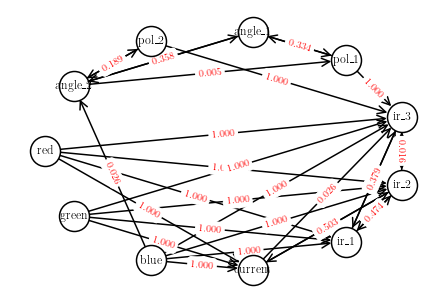

    \begin{tikzpicture}
        \node[circle, inner sep=0.12em] (0) at (-0.811, 1.262) {$R$};
        \node[circle, inner sep=0.12em] (1) at (-1.364, 0.623) {$G$};
        \node[circle, inner sep=0.12em] (2) at (-1.485, -0.213) {$B$};
        \node[circle, inner sep=0.12em] (3) at (-1.134, -0.982) {$\tilde{C}$};
        \node[circle, inner sep=0.12em] (4) at (-0.423, -1.439) {$\tilde{I}_1$};
        \node[circle, inner sep=0.12em] (5) at (0.423, -1.439) {$\tilde{I}_2$};
        \node[circle, inner sep=0.12em] (6) at (1.134, -0.982) {$\tilde{I}_3$};
        \node[circle, inner sep=0.12em] (7) at (1.485, -0.213) {$\theta_1$};
        \node[circle, inner sep=0.12em] (8) at (1.364, 0.623) {$\tilde{\theta}_1$};
        \node[circle, inner sep=0.12em] (9) at (0.811, 1.262) {$\theta_2$};
        \node[circle, inner sep=0.12em] (10) at (0.000, 1.500) {$\tilde{\theta}_2$};
        \begin{scope}[]
            \draw[->, bend right=-4] (10) edge[color={rgb,1:red,0.9947368421052631;green,0.99473684

In [35]:
print(ges_lambdas, Ns)
i = 2
j = 0
print(f"lambda={ges_lambdas[i]}, n={Ns[j]}")
estimates = ges_results['estimates'][0,i,j,:]
dags = []
for e in estimates:
    dags += list(gnies.utils.all_dags(e))        
    average = np.sum(dags, axis=0) / len(dags)
sempler.plot.plot_graph(average, labels=test_cases['variables'], weights=True)
        

print(graph_to_tikz(average, radius=1.5, bend=10, labels=[latex_name(v) for v in test_cases['variables']], weights="color"))

#### UT-IGSP

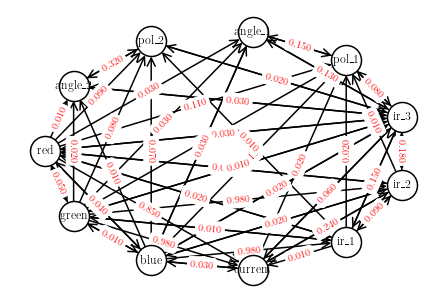

    \begin{tikzpicture}
        \node[circle, inner sep=0.12em] (0) at (-0.811, 1.262) {$R$};
        \node[circle, inner sep=0.12em] (1) at (-1.364, 0.623) {$G$};
        \node[circle, inner sep=0.12em] (2) at (-1.485, -0.213) {$B$};
        \node[circle, inner sep=0.12em] (3) at (-1.134, -0.982) {$\tilde{C}$};
        \node[circle, inner sep=0.12em] (4) at (-0.423, -1.439) {$\tilde{I}_1$};
        \node[circle, inner sep=0.12em] (5) at (0.423, -1.439) {$\tilde{I}_2$};
        \node[circle, inner sep=0.12em] (6) at (1.134, -0.982) {$\tilde{I}_3$};
        \node[circle, inner sep=0.12em] (7) at (1.485, -0.213) {$\theta_1$};
        \node[circle, inner sep=0.12em] (8) at (1.364, 0.623) {$\tilde{\theta}_1$};
        \node[circle, inner sep=0.12em] (9) at (0.811, 1.262) {$\theta_2$};
        \node[circle, inner sep=0.12em] (10) at (0.000, 1.500) {$\tilde{\theta}_2$};
        \begin{scope}[]
            \draw[->, bend left=8] (0) edge[color={rgb,1:red,0.99;green,0.99;blue,0.99}] (1);
     

In [36]:
ut_igsp_args, ut_igsp_results
estimates = ut_igsp_results['estimates'][0,UTIGSP_BETA,0,0,:]
average = np.sum(estimates, axis=0) / len(estimates)
sempler.plot.plot_graph(average, labels=test_cases['variables'], weights=True)
        
from causalchamber.ground_truth import latex_name
print(graph_to_tikz(average, radius=1.5, bend=10, labels=[latex_name(v) for v in test_cases['variables']], weights="color"))

## Plot & graphs for $\mathcal{I}^\star = \{\theta_1, \theta_2\}$

In [37]:
directory = "light_tunnel_experiments/dataset_1718986276_light_tunnel_tag:pols/"

test_cases = utils.read_pickle(directory + 'test_cases.pickle')
Ns = sorted(test_cases['Ns'])

**GnIES**

In [38]:
gnies_args, gnies_results = utils.read_pickle(directory + "compiled_results_gnies_fb.pickle")
ground_truth, gnies_metrics = utils.read_pickle(directory + "metrics_gnies_fb.pickle")
gnies_lambdas = gnies_args[2]
print(gnies_lambdas)
print(gnies_metrics[metrics.success_metric].mean())

gnies_x = np.nanmean(gnies_metrics[metrics.type_1_structc], axis=(0,3))
gnies_y = np.nanmean(gnies_metrics[metrics.type_2_structc], axis=(0,3))

[0.01, 0.25, 0.5, 0.75, 1.0, 2.0]
1.0


**GnIES w. means**

In [39]:
gniesm_args, gniesm_results = utils.read_pickle(directory + "compiled_results_gnies_fb_means.pickle")
ground_truth, gniesm_metrics = utils.read_pickle(directory + "metrics_gnies_fb_means.pickle")
gniesm_lambdas = gniesm_args[2]
print(gniesm_lambdas)
print(gniesm_metrics[metrics.success_metric].mean())

gniesm_x = np.nanmean(gniesm_metrics[metrics.type_1_structc], axis=(0,3))
gniesm_y = np.nanmean(gniesm_metrics[metrics.type_2_structc], axis=(0,3))

[0.01, 0.25, 0.5, 0.75, 1.0, 2.0]
1.0


**UT-IGSP**

In [40]:
ut_igsp_args, ut_igsp_results = utils.read_pickle(directory + "compiled_results_ut_igsp_gauss_obs:0.pickle")
ground_truth, utigsp_metrics = utils.read_pickle(directory + "metrics_ut_igsp_gauss_obs:0.pickle")
utigsp_alphas, utigsp_betas = ut_igsp_args[1], ut_igsp_args[2]
print(utigsp_alphas, utigsp_betas)
print(utigsp_metrics[metrics.success_metric].mean(axis=(0,1,2,4)))
print(utigsp_metrics[metrics.type_1_structc].shape)

idx = list(range(len(utigsp_alphas)))
utigsp_x = np.nanmean(utigsp_metrics[metrics.type_1_structc], axis=(0,4))[idx,[UTIGSP_BETA]]
utigsp_y = np.nanmean(utigsp_metrics[metrics.type_2_structc], axis=(0,4))[idx,[UTIGSP_BETA]]

[0.001, 0.01, 0.05, 0.1, 0.2, 0.3, 0.4, 0.5] [1e-10, 0.001, 0.01, 0.1]
[1.]
(1, 8, 4, 1, 100)


**UT-IGSP with HSIC tests**

In [41]:
ut_igspH_args, ut_igspH_results = utils.read_pickle(directory + "compiled_results_ut_igsp_hsic_obs:0.pickle")
ground_truth, utigspH_metrics = utils.read_pickle(directory + "metrics_ut_igsp_hsic_obs:0.pickle")
utigspH_alphas, utigspH_betas = ut_igspH_args[1], ut_igspH_args[2]
print(utigspH_alphas, utigspH_betas)
print(utigspH_metrics[metrics.success_metric].mean(axis=(0,1,2,4)))
print(utigspH_metrics[metrics.type_1_structc].shape)

idx = list(range(len(utigspH_alphas)))
utigspH_x = np.nanmean(utigspH_metrics[metrics.type_1_structc], axis=(0,4))[idx,[UTIGSP_BETA]]
utigspH_y = np.nanmean(utigspH_metrics[metrics.type_2_structc], axis=(0,4))[idx,[UTIGSP_BETA]]

[0.001, 0.01, 0.05, 0.1, 0.2, 0.3, 0.4, 0.5] [1e-10, 0.001, 0.01, 0.1]
[1.]
(1, 8, 4, 1, 100)


**GES**

In [42]:
ges_args, ges_results = utils.read_pickle(directory + "compiled_results_ges.pickle")
ground_truth, ges_metrics = utils.read_pickle(directory + "metrics_ges.pickle")
ges_lambdas = ges_args[2]
print(ges_lambdas)
print(ges_metrics[metrics.success_metric].mean())

ges_x = np.nanmean(ges_metrics[metrics.type_1_structc], axis=(0,3))
ges_y = np.nanmean(ges_metrics[metrics.type_2_structc], axis=(0,3))

[0.01, 0.25, 0.5, 0.75, 1.0, 2.0]
1.0


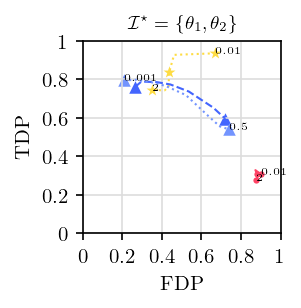

In [43]:
# -------------------------------------------------------------------
# Plot
text = True
textsize = 5
lineopts = {'linewidth': 1}
ticks = [0, 0.2, 0.4, 0.6, 0.8, 1]
marker = {'gnies': '.',
          'gnies_means': '.',
          'gnies_rank': '.',
          'ges': '*',
          'ut_igsp': '^',
          'ut_igsp+': '^',
          'sort': 's',
          'sortp': 'X',           
}
style = {'gnies': '-',
         'gnies_means': '--',
         'gnies_rank': ':',
         'ges': ':',
         'ut_igsp': ':',
         'ut_igsp+': '--',
         'sort': ':',
         'sortp': '--',
           
}
color = {'gnies': colors[0],
         'gnies_means': colors[0],
         'gnies_rank': colorsa[0],
         'ges': colors[1],
         'ut_igsp': colors[4],
         'ut_igsp+': colors[5],
         'sort': colors[2],
         'sortp': colors[2],
         
}

print_names = {'gnies': 'GnIES',
               #'gnies_means': 'GnIES means',
               #'gnies_rank': 'GnIES-rank',
               'ges': 'GES',
               'ut_igsp': 'UT-IGSP',
               'ut_igsp+': 'UT-IGSP*',
               #'sort': 'sortnregress',         
               #'sortp': 'sortnregress',
}

def plot_metric(ax, values_x, values_y, lambdas, method, points, text, gray=False):
    c = '#aaaaaa' if gray else color[method]
    values_y = 1 - values_y
    ax.plot(values_x, values_y, color=c, linestyle=style[method], **lineopts)
    for j, l in enumerate(lambdas):
        #ax.scatter(values_x[j], values_y[j], color=color[method], marker=".", linewidth=0)
        if j==0 and text[0] is not None:
            if l < 0.001:
                l = np.log10(l)
                fmt = "$10^{%d}$"
            else:
                fmt = "$"+text[0]+"$"
            ax.text(values_x[j], values_y[j], fmt % l, fontsize=textsize, ha="left")
        if l==lambdas[-1] and text[1] is not None:
            ax.text(values_x[j], values_y[j], ("$"+text[1]+"$") % l, fontsize=textsize, ha="left")
        if j in points:
            ax.scatter(values_x[j], values_y[j], color=c, marker=marker[method], linewidth=0)
            
def set_ax(ax, yticks=True):
    ax.set_xlim([0,1])
    ax.set_ylim([0,1])
    ax.set_xlabel('FDP')    
    ax.set_ylabel('TDP') if yticks else None
    ax.set_yticks(ticks)
    ax.set_xticks(ticks)
    ax.set_xticklabels(ticks)
    ax.set_yticklabels(ticks) if yticks else ax.set_yticklabels([])


gs = gridspec.GridSpec(1, 1, wspace=0.10, hspace=0.2)
plt.figure(figsize=(1.7,1.7), dpi=150)
ax = plt.gca()

for i,n in enumerate(Ns):
    plt.subplot(gs[i])
    ax = plt.gca()
    if i==0:
        ax0 = ax
    
    # Plot GES
    plot_metric(ax, ges_x[:,i], ges_y[:,i], ges_lambdas, 'ges', [0,2,len(ges_lambdas)-1], ["%0.2f","%d"])    
    
    # Plot GnIES
    plot_metric(ax, gnies_x[:,i], gnies_y[:,i], gnies_lambdas, 'gnies', [0,2,len(gnies_lambdas)-1], ["%0.2f","%d"])
    
    # Plot GnIES means
    #plot_metric(ax, gniesm_x[:,i], gniesm_y[:,i], gniesm_lambdas, 'gnies_means', [0,2,len(gniesm_lambdas)-1], [None if n==10 else "%0.2f","%0.1f"])
                
    # Plot UT-IGSP HSIC
    plot_metric(ax, utigspH_x[:,i], utigspH_y[:,i], utigspH_alphas, 'ut_igsp+', [0,len(utigsp_alphas)-1], [None, None])
    
    # Plot UT-IGSP
    plot_metric(ax, utigsp_x[:,i], utigsp_y[:,i], utigsp_alphas, 'ut_igsp', [0,len(utigsp_alphas)-1], ["%0.3f","%0.1f"])

    
    
    set_ax(ax, yticks=i==0)
    ax.set_title("%d obs./environment" % n)    
    ax.set_title(r"$\mathcal{I}^\star = \{\theta_1, \theta_2\}$", fontsize=9)

plt.grid(color='#dddddd')
plt.savefig('figures/figure_lt_pols.pdf', bbox_inches='tight')

### Graphs

#### GnIES

[0.01, 0.25, 0.5, 0.75, 1.0, 2.0] [1000]
lambda=0.5, n=1000


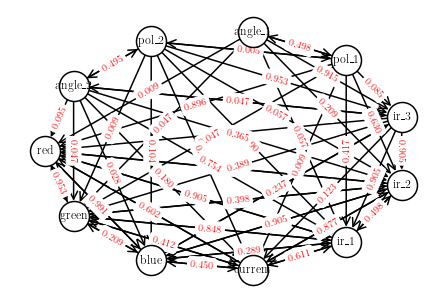

    \begin{tikzpicture}
        \node[circle, inner sep=0.12em] (0) at (-0.811, 1.262) {$R$};
        \node[circle, inner sep=0.12em] (1) at (-1.364, 0.623) {$G$};
        \node[circle, inner sep=0.12em] (2) at (-1.485, -0.213) {$B$};
        \node[circle, inner sep=0.12em] (3) at (-1.134, -0.982) {$\tilde{C}$};
        \node[circle, inner sep=0.12em] (4) at (-0.423, -1.439) {$\tilde{I}_1$};
        \node[circle, inner sep=0.12em] (5) at (0.423, -1.439) {$\tilde{I}_2$};
        \node[circle, inner sep=0.12em] (6) at (1.134, -0.982) {$\tilde{I}_3$};
        \node[circle, inner sep=0.12em] (7) at (1.485, -0.213) {$\theta_1$};
        \node[circle, inner sep=0.12em] (8) at (1.364, 0.623) {$\tilde{\theta}_1$};
        \node[circle, inner sep=0.12em] (9) at (0.811, 1.262) {$\theta_2$};
        \node[circle, inner sep=0.12em] (10) at (0.000, 1.500) {$\tilde{\theta}_2$};
        \begin{scope}[]
            \draw[->, bend left=2] (6) edge[color={rgb,1:red,0.995260663507109;green,0.995260663507

In [44]:
print(gnies_lambdas, Ns)
i = 2
j = 0
print(f"lambda={gnies_lambdas[i]}, n={Ns[j]}")
estimates = gnies_results['estimates'][0,i,j,:]
dags = []
for e in estimates:
    dags += list(gnies.utils.all_dags(e))        
    average = np.sum(dags, axis=0) / len(dags)
sempler.plot.plot_graph(average, labels=test_cases['variables'], weights=True)
        

print(graph_to_tikz(average, radius=1.5, bend=10, labels=[latex_name(v) for v in test_cases['variables']], weights="color"))

#### GES

[0.01, 0.25, 0.5, 0.75, 1.0, 2.0] [1000]
lambda=0.5, n=1000


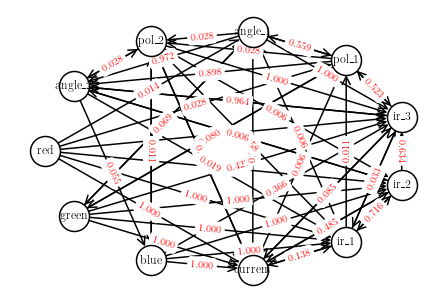

    \begin{tikzpicture}
        \node[circle, inner sep=0.12em] (0) at (-0.811, 1.262) {$R$};
        \node[circle, inner sep=0.12em] (1) at (-1.364, 0.623) {$G$};
        \node[circle, inner sep=0.12em] (2) at (-1.485, -0.213) {$B$};
        \node[circle, inner sep=0.12em] (3) at (-1.134, -0.982) {$\tilde{C}$};
        \node[circle, inner sep=0.12em] (4) at (-0.423, -1.439) {$\tilde{I}_1$};
        \node[circle, inner sep=0.12em] (5) at (0.423, -1.439) {$\tilde{I}_2$};
        \node[circle, inner sep=0.12em] (6) at (1.134, -0.982) {$\tilde{I}_3$};
        \node[circle, inner sep=0.12em] (7) at (1.485, -0.213) {$\theta_1$};
        \node[circle, inner sep=0.12em] (8) at (1.364, 0.623) {$\tilde{\theta}_1$};
        \node[circle, inner sep=0.12em] (9) at (0.811, 1.262) {$\theta_2$};
        \node[circle, inner sep=0.12em] (10) at (0.000, 1.500) {$\tilde{\theta}_2$};
        \begin{scope}[]
            \draw[->, bend left=2] (4) edge[color={rgb,1:red,0.9944903581267217;green,0.99449035812

In [45]:
print(ges_lambdas, Ns)
i = 2
j = 0
print(f"lambda={ges_lambdas[i]}, n={Ns[j]}")
estimates = ges_results['estimates'][0,i,j,:]
dags = []
for e in estimates:
    dags += list(gnies.utils.all_dags(e))        
    average = np.sum(dags, axis=0) / len(dags)
sempler.plot.plot_graph(average, labels=test_cases['variables'], weights=True)
        

print(graph_to_tikz(average, radius=1.5, bend=10, labels=[latex_name(v) for v in test_cases['variables']], weights="color"))

#### UT-IGSP

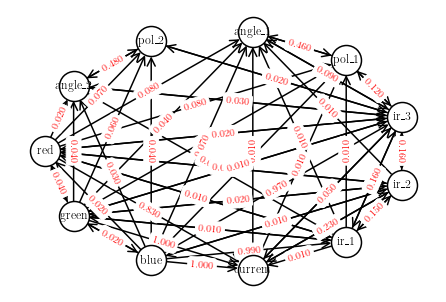

    \begin{tikzpicture}
        \node[circle, inner sep=0.12em] (0) at (-0.811, 1.262) {$R$};
        \node[circle, inner sep=0.12em] (1) at (-1.364, 0.623) {$G$};
        \node[circle, inner sep=0.12em] (2) at (-1.485, -0.213) {$B$};
        \node[circle, inner sep=0.12em] (3) at (-1.134, -0.982) {$\tilde{C}$};
        \node[circle, inner sep=0.12em] (4) at (-0.423, -1.439) {$\tilde{I}_1$};
        \node[circle, inner sep=0.12em] (5) at (0.423, -1.439) {$\tilde{I}_2$};
        \node[circle, inner sep=0.12em] (6) at (1.134, -0.982) {$\tilde{I}_3$};
        \node[circle, inner sep=0.12em] (7) at (1.485, -0.213) {$\theta_1$};
        \node[circle, inner sep=0.12em] (8) at (1.364, 0.623) {$\tilde{\theta}_1$};
        \node[circle, inner sep=0.12em] (9) at (0.811, 1.262) {$\theta_2$};
        \node[circle, inner sep=0.12em] (10) at (0.000, 1.500) {$\tilde{\theta}_2$};
        \begin{scope}[]
            \draw[->, bend left=8] (0) edge[color={rgb,1:red,0.99;green,0.99;blue,0.99}] (1);
     

In [46]:
ut_igsp_args, ut_igsp_results
estimates = ut_igsp_results['estimates'][0,UTIGSP_BETA,0,0,:]
average = np.sum(estimates, axis=0) / len(estimates)
sempler.plot.plot_graph(average, labels=test_cases['variables'], weights=True)
        
from causalchamber.ground_truth import latex_name
print(graph_to_tikz(average, radius=1.5, bend=10, labels=[latex_name(v) for v in test_cases['variables']], weights="color"))